In [1]:
from pathlib import Path
import json, re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.home() / "OneDrive - Bryant University" / "Desktop" / "data projects" / "Messages"

URL_RE = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
EMOJI_RE = re.compile(r"<a?:\w+:\d+>")                 # custom emojis <:name:123>
UNICODE_EMOJI_RE = re.compile(r"[\U0001F300-\U0001FAFF\U00002700-\U000027BF]+")
CODE_BLOCK_RE = re.compile(r"```[\s\S]*?```", re.MULTILINE)
INLINE_CODE_RE = re.compile(r"`[^`]+`")
MARKDOWN_RE = re.compile(r"[*_~>|]")
PUNCT_RE = re.compile(r"[\.,;:!?\(\)\[\]\{\}\"'\\/\\-]+")

TOKEN_RE = re.compile(r"[A-Za-z0-9#@']+")

# Stopwords + casual fillers
STOP = set("""
don the a an and or but if then for to of in on at by from as is are was were ve re nt ive yea ll
i you he she it we they me him her them my your his her their our this that these those not no yes yeah ok okay
just like so very really about am im i'm you're we're they're it's isn't aren't wasn't weren't don't doesn't didn't dont didnt doesnt werent wasnt arent isnt
ur urs u youre youre's its have go all too well also gonna bc theyre there thats had didn rly tho hes isn hav
""".split())


def clean_text(t: str): 
    if not t:
        return ""
    t = URL_RE.sub(" ", t)
    t = EMOJI_RE.sub(" ", t)
    t = UNICODE_EMOJI_RE.sub(" ", t)
    t = CODE_BLOCK_RE.sub(" ", t)
    t = INLINE_CODE_RE.sub(" ", t)
    t = MARKDOWN_RE.sub(" ", t)
    t = PUNCT_RE.sub(" ", t)
    return t

def tokenize(t: str):
    return [w for w in TOKEN_RE.findall(t.lower()) if w and w not in STOP and len(w) >= 2]



In [2]:
def read_json_array(path: Path):
    text = path.read_text(encoding="utf-8", errors="ignore").strip()
    try:
        obj = json.loads(text)
        if isinstance(obj, list):
            return obj
        elif isinstance(obj, dict):
            return [obj]
    except Exception:
        arr = []
        for line in text.splitlines():
            line = line.strip()
            if not line: 
                continue
            try:
                rec = json.loads(line)
                if isinstance(rec, dict):
                    arr.append(rec)
            except:
                pass
        return arr

def discover_channel_folders(root: Path):
    folders = []
    for p in root.iterdir():
        if p.is_dir() and (p / "messages.json").exists():
            folders.append(p)
    return sorted(folders)

def read_channel_name(folder: Path) -> str:
    for fp in [folder / "channel.json", folder / "channel"]:
        if fp.exists():
            try:
                data = json.loads(fp.read_text(encoding="utf-8", errors="ignore").strip())
                if isinstance(data, dict):
                    lower = {k.lower(): v for k, v in data.items()}
                    return (
                        lower.get("name") or lower.get("channel_name") or
                        data.get("Name") or data.get("ChannelName") or folder.name
                    )
            except Exception:
                pass
    return folder.name

def iter_messages(folder: Path):
    fp = folder / "messages.json"
    if fp.exists():
        for rec in read_json_array(fp):
            yield rec

def extract_tokens_from_record(rec: dict):
    contents = rec.get("Contents") or rec.get("contents") or ""
    cleaned = clean_text(str(contents))
    tokens = tokenize(cleaned)
    return tokens


In [3]:
global_ctr = Counter()
channel_ctrs = defaultdict(Counter)

folders = discover_channel_folders(ROOT)
total_msgs = 0

for folder in folders:
    ch_name = read_channel_name(folder)
    for rec in iter_messages(folder):
        total_msgs += 1
        toks = extract_tokens_from_record(rec)
        if toks:
            global_ctr.update(toks)
            channel_ctrs[ch_name].update(toks)

print("Total messages processed:", total_msgs)
print("Unique words:", len(global_ctr))

df_global = pd.DataFrame(global_ctr.most_common(), columns=["word","count"])
if not df_global.empty:
    df_global["percent"] = df_global["count"] / df_global["count"].sum()

rows = []
for ch, ctr in channel_ctrs.items():
    for w, c in ctr.most_common():
        rows.append({"channel": ch, "word": w, "count": c})
df_channel = pd.DataFrame(rows)

df_global.head(50)


Total messages processed: 385584
Unique words: 39338


,word,count,percent
0,what,14049,0.016055
1,do,11603,0.013259
2,oh,9693,0.011077
3,why,8778,0.010031
4,be,8737,0.009984
5,lmao,7702,0.008802
6,can,6915,0.007902
7,how,6348,0.007254
8,one,6166,0.007046
9,with,5864,0.006701


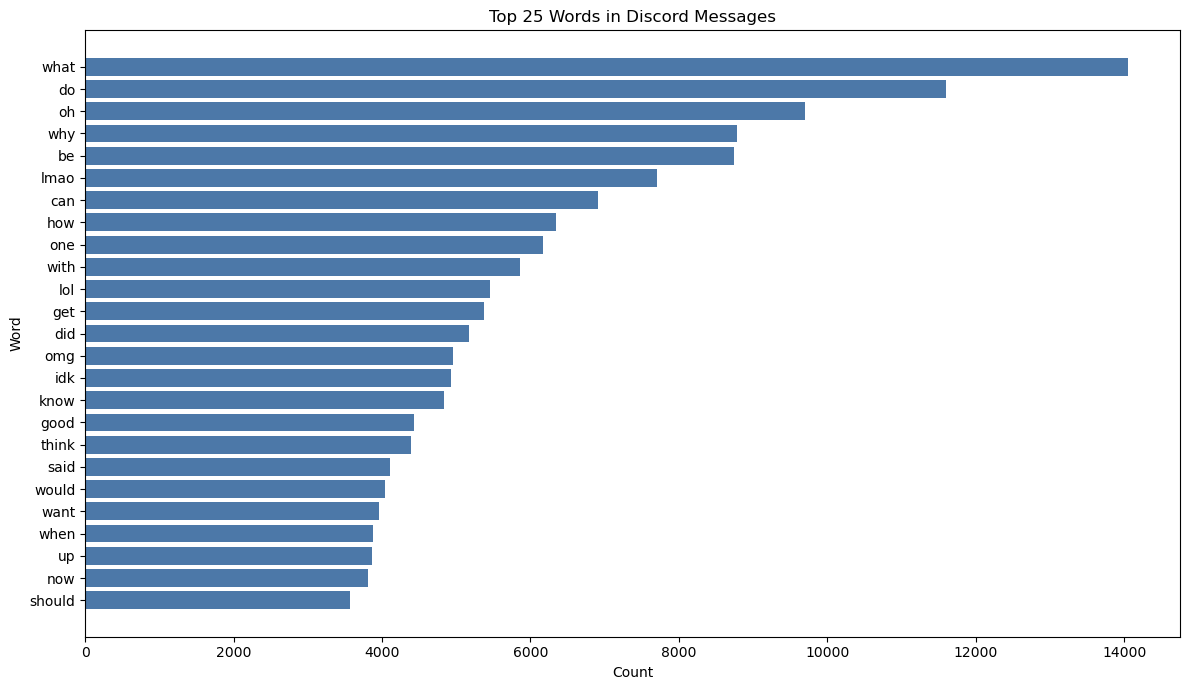

In [4]:

# Plot top N global words
TOP_N = 25
top = df_global.head(TOP_N)

plt.figure(figsize=(12,7))
plt.barh(top["word"][::-1], top["count"][::-1], color="#4C78A8")
plt.title(f"Top {TOP_N} Words in Discord Messages")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


Saved CSVs and chart to: discord_analysis


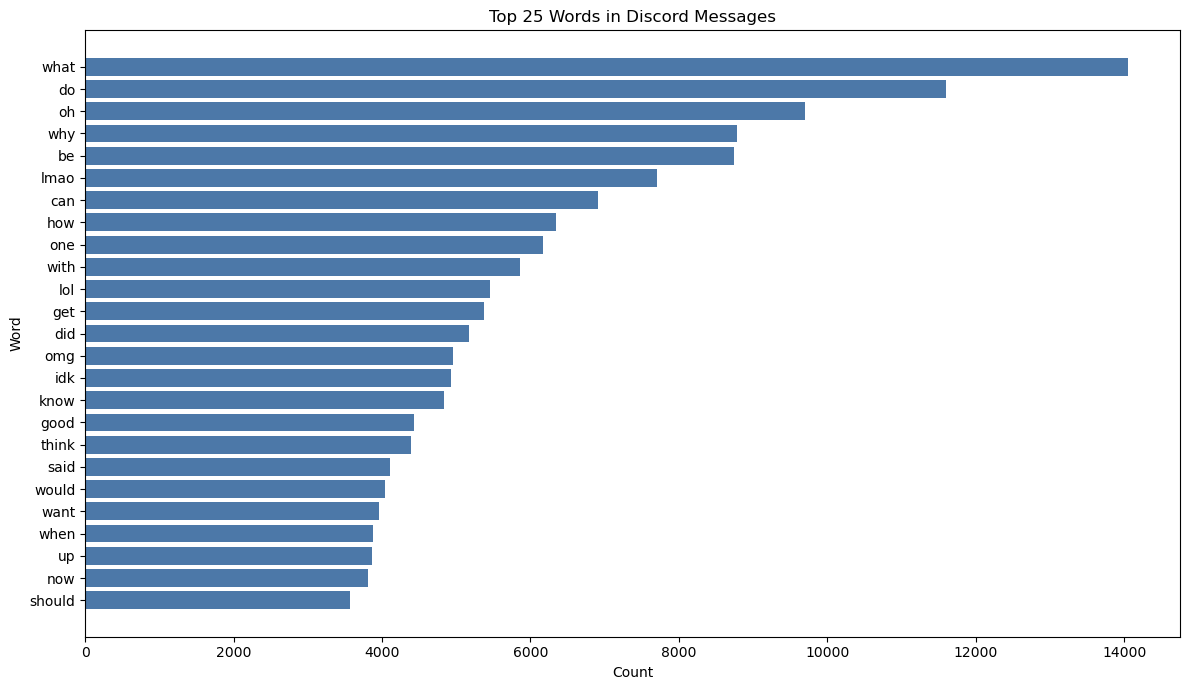

In [5]:

OUT = Path("./discord_analysis")
OUT.mkdir(parents=True, exist_ok=True)

df_global.to_csv(OUT / "word_frequencies.csv", index=False)
df_channel.to_csv(OUT / "per_channel_word_frequencies.csv", index=False)

TOP_N = 25
top = df_global.head(TOP_N)
plt.figure(figsize=(12,7))
plt.barh(top["word"][::-1], top["count"][::-1], color="#4C78A8")
plt.title(f"Top {TOP_N} Words in Discord Messages")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig(OUT / "top_words.png")
print("Saved CSVs and chart to:", OUT)


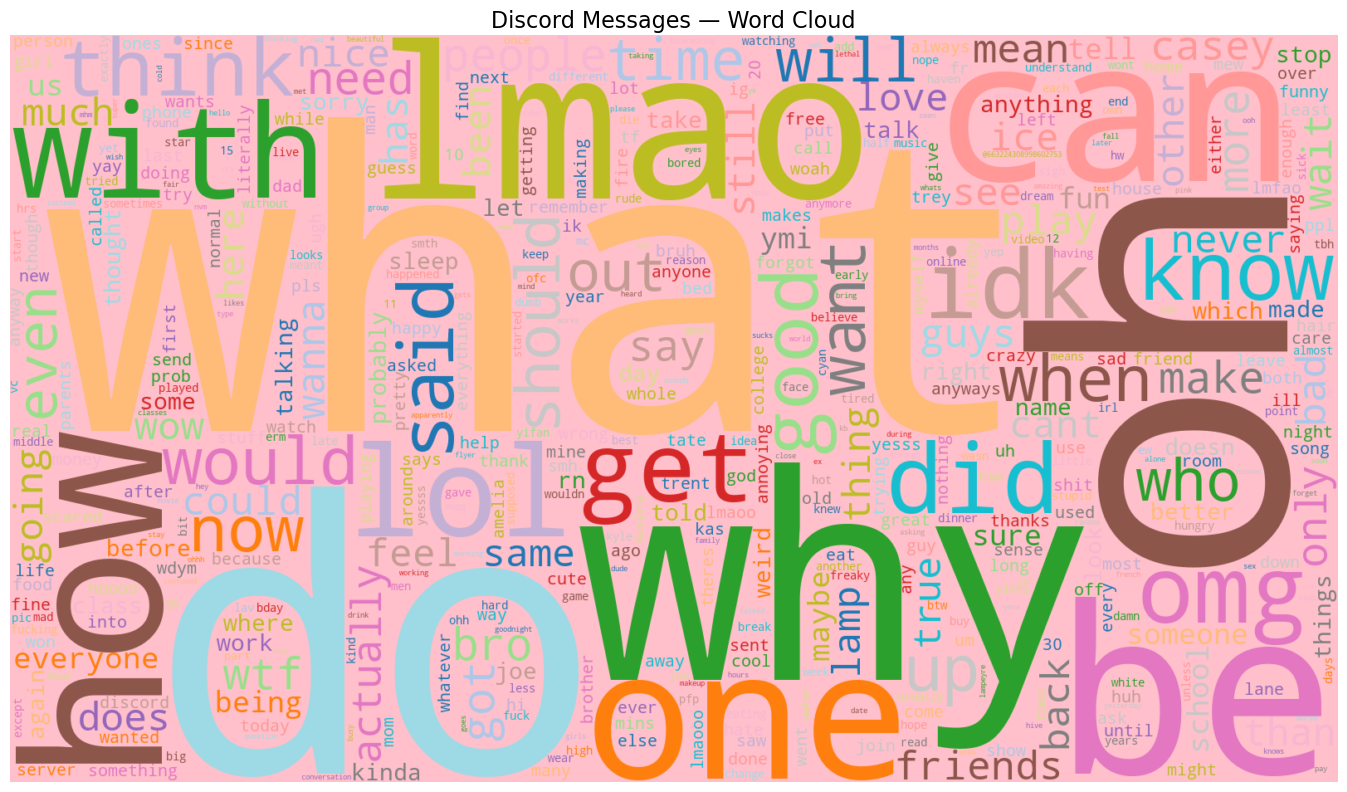

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

freq_dict = dict(df_global.set_index("word")["count"])

wc = WordCloud(
    width=1600, height=900,
    background_color="pink",
    prefer_horizontal=0.9,
    colormap="tab20",
    max_words=500,
    normalize_plurals=True
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(14, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Discord Messages — Word Cloud", fontsize=16)
plt.tight_layout()
plt.show()


In [7]:
print(global_ctr['kas'], global_ctr['kasixna'], global_ctr['lamp'], global_ctr['lampeyre'])

613 512 1601 312
